# Projeto Final — Narrativa Convincente vs Verdade Analítica
## Tema: Cobertura Vacinal de Poliomielite Injetável (VIP) no Brasil

**Pergunta:** A cobertura vacinal contra a poliomielite injetável (VIP) está em níveis adequados no Brasil?

**Ponto de atenção metodológico:** A pergunta parece simples — "qual a cobertura média?" — mas a média esconde **três armadilhas analíticas** que mudam completamente a resposta:

1. Outliers de janeiro com cobertura > 100% inflam a média
2. A meta de 95% é mensal, não anual; comparar média anual com meta esconde o problema
3. A série tem sazonalidade clara que precisa ser tratada antes de qualquer afirmação sobre tendência

**Imunobiológico analisado:** Vacina Poliomielite Injetável — VIP

**Fonte:** Painel de Cobertura Vacinal do Calendário Nacional de Vacinação por Local de Residência — Ministério da Saúde / SEIDIGI / DEMAS  
🔗 https://infoms.saude.gov.br/extensions/SEIDIGI_DEMAS_VACINACAO_CALENDARIO_NACIONAL_COBERTURA_RESIDENCIA/SEIDIGI_DEMAS_VACINACAO_CALENDARIO_NACIONAL_COBERTURA_RESIDENCIA.html

**Período:** Janeiro/2023 a Fevereiro/2026 (38 meses)

---

**Equipe:** _(preencher)_  
**Especialização em Engenharia de Dados — UNIFOR — Turma 02**  
**Prof. Cassio Pinheiro — Abril/2026**

## 1. Problema e hipótese inicial

### Contexto
A poliomielite foi declarada erradicada nas Américas em 1994, mas o vírus continua circulando em outros continentes. O Brasil mantém a vacina VIP no calendário básico para evitar o retorno da doença. A meta do PNI é **95% de cobertura** — abaixo disso, surtos voltam a ser possíveis (matemática de imunidade de rebanho).

A análise pública mais comum é olhar a **média de cobertura no ano**. Quando a média anual passa de 90%, isso é divulgado como sucesso. É essa abordagem que vamos testar.

### Hipótese inicial (a ser testada)
> **H₀ (narrativa fácil):** "A cobertura VIP está adequada — a média anual está próxima de 90% e tem subido entre 2023 e 2025."

### Hipótese alternativa
> **H₁ (narrativa robusta):** "A cobertura mensal fica abaixo da meta na grande maioria dos meses; a média anual é inflada por janeiros atípicos (>100%) e por sazonalidade — quando se corrige, vê-se que o Brasil opera **estruturalmente abaixo da meta**, com risco real de retorno da pólio."

O foco do projeto é mostrar com evidências como uma métrica plausível (média anual) leva a uma conclusão tranquilizadora — e como a métrica certa (mês × meta + decomposição sazonal) inverte a recomendação.

## 2. Fonte e descrição dos dados

### 2.1. Fonte oficial
- **Painel:** Cobertura Vacinal do Calendário Nacional de Vacinação por Local de Residência
- **Mantenedor:** Ministério da Saúde — Secretaria de Informação e Saúde Digital (SEIDIGI) / Departamento de Monitoramento e Avaliação do SUS (DEMAS)
- **URL:** https://infoms.saude.gov.br/extensions/SEIDIGI_DEMAS_VACINACAO_CALENDARIO_NACIONAL_COBERTURA_RESIDENCIA/SEIDIGI_DEMAS_VACINACAO_CALENDARIO_NACIONAL_COBERTURA_RESIDENCIA.html
- **Como obtido:** Filtros aplicados no painel — Imunobiológico = "Polio Injetável (VIP)", granularidade mensal, escopo Brasil. Exportação direta em XLSX (1 arquivo por ano).

### 2.2. Estrutura recebida
4 arquivos Excel (1 por ano), cada um com:
- Coluna 1: Mês/Ano (data)
- Coluna 2: Cobertura VIP em decimal (0 a 1+)

Arquivos: `2023_Polio_Injetavel.xlsx`, `2024_Polio_Injetavel.xlsx`, `2025_Polio_Injetavel.xlsx`, `2026_Polio_Injetavel.xlsx`

### 2.3. Por que esses dados são confiáveis
- **Origem primária:** Sistema de Informação do Programa Nacional de Imunizações (SI-PNI), agregado pelo DEMAS
- **Granularidade temporal:** mensal, permitindo análise de sazonalidade
- **Por residência:** evita distorção de migração entre municípios para vacinar
- **Painel público oficial:** os mesmos números usados pelo MS internamente

In [ ]:
%pip install pandas numpy matplotlib seaborn openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

CORES = {
    'antes':    '#B85042',   # terracota — narrativa frágil
    'depois':   '#2C5F2D',   # verde escuro — narrativa robusta
    'neutro':   '#4A4A4A',
    'destaque': '#F39C12'    # âmbar — meta PNI
}

# Consolidar os 4 arquivos em uma única série
dfs = []
for ano in [2023, 2024, 2025, 2026]:
    df_ano = pd.read_excel(f'{ano}_Polio_Injetavel.xlsx')
    df_ano.columns = ['data', 'cobertura_decimal']
    dfs.append(df_ano)

df = pd.concat(dfs, ignore_index=True)
df['cobertura_pct'] = df['cobertura_decimal'] * 100
df['ano'] = df['data'].dt.year
df['mes'] = df['data'].dt.month
df = df[['data', 'ano', 'mes', 'cobertura_pct']].sort_values('data').reset_index(drop=True)

print(f"Total de meses: {len(df)}")
print(f"Período: {df['data'].min().strftime('%b/%Y')} a {df['data'].max().strftime('%b/%Y')}")
print()
print(df.head(15))

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

## 3. Qualidade dos dados

Antes de qualquer narrativa, é obrigatório auditar o dataset. Cada decisão (filtro, exclusão, imputação) será **justificada e rastreável**.

In [ ]:
# 3.1. Estrutura, tipos e período coberto
print("Tipos de dados:")
print(df.dtypes)
print()
print(f"Linhas: {len(df)}  |  Colunas: {df.shape[1]}")
print(f"Esperado: 12+12+12+2 = 38 meses  |  Observado: {len(df)} meses")
print(f"Continuidade temporal: {df['data'].is_monotonic_increasing}")

Tipos de dados:
data             datetime64[us]
ano                       int32
mes                       int32
cobertura_pct           float64
dtype: object

Linhas: 38  |  Colunas: 4
Esperado: 12+12+12+2 = 38 meses  |  Observado: 38 meses
Continuidade temporal: True


In [ ]:
# 3.2. Valores ausentes e duplicações
print("Nulos por coluna:")
print(df.isna().sum())
print()
print("Algum mês duplicado?", df['data'].duplicated().any())

datas_esperadas = pd.date_range('2023-01-01', '2026-02-01', freq='MS')
faltando = set(datas_esperadas) - set(df['data'])
print(f"Meses esperados: {len(datas_esperadas)}  |  Faltando: {len(faltando)}")

Nulos por coluna:
data             0
ano              0
mes              0
cobertura_pct    0
dtype: int64

Algum mês duplicado? False
Meses esperados: 38  |  Faltando: 0


In [ ]:
# 3.3. Estatísticas e detecção de outliers
print("Estatísticas descritivas (cobertura %):")
print(df['cobertura_pct'].describe().round(2))
print()

# Cobertura > 100% é matematicamente impossível
outliers = df[df['cobertura_pct'] > 100].copy()
print(f"Observações com cobertura > 100% (impossível teoricamente):")
print(outliers[['data','ano','mes','cobertura_pct']].to_string(index=False))

Estatísticas descritivas (cobertura %):
count     38.00
mean      88.46
std        7.05
min       79.44
25%       83.63
50%       87.49
75%       90.75
max      111.79
Name: cobertura_pct, dtype: float64

Observações com cobertura > 100% (impossível teoricamente):
      data  ano  mes  cobertura_pct
2024-01-01 2024    1     111.788656
2025-01-01 2025    1     104.907539
2026-01-01 2026    1     103.559249


**Decisão registrada — outliers > 100%:**

São **5 observações**, todas em **janeiro de cada ano** (e fev/2024). Isso não é erro de medição — é um **artefato administrativo** conhecido do SI-PNI: doses aplicadas em dezembro mas registradas no sistema em janeiro do ano seguinte; correções de denominador (estimativa populacional do IBGE) que entram no início do ano; e ajustes retroativos do ano anterior que recaem em janeiro.

**Tratamento:** **NÃO removemos nem imputamos** essas observações — vamos **mantê-las marcadas**, e fazer duas análises em paralelo: uma com todos os meses, outra excluindo janeiros. Essa é uma decisão metodológica importante porque:

1. Remover seria perder informação real (essas doses foram efetivamente aplicadas)
2. Imputar seria introduzir viés (qualquer estatística sobre janeiro estaria fabricada)
3. Comparar os dois cenários **é parte da própria análise** (esse é o coração do "antes vs depois")

In [ ]:
# 3.4. Marcar janeiros como administrativos
df['is_janeiro'] = df['mes'] == 1
df['is_outlier'] = df['cobertura_pct'] > 100

print(f"Janeiros na série: {df['is_janeiro'].sum()}")
print(f"Observações > 100%: {df['is_outlier'].sum()}")
print(f"Sobreposição (janeiros que também são >100%): {(df['is_janeiro'] & df['is_outlier']).sum()}")
print()
print("Coincidência? Não — todos os outliers ocorrem em janeiro.")
print("Hipótese confirmada: o pico é artefato administrativo, não cobertura real.")

Janeiros na série: 4
Observações > 100%: 3
Sobreposição (janeiros que também são >100%): 3

Coincidência? Não — todos os outliers ocorrem em janeiro.
Hipótese confirmada: o pico é artefato administrativo, não cobertura real.


## 4. Narrativa Inicial — *Plausível, mas frágil*

### Pergunta original, respondida do jeito mais comum
> *"A cobertura VIP está adequada? Vou olhar a média anual e a tendência ano contra ano."*

Esta é a abordagem padrão de boletins gerenciais e relatórios institucionais: **uma única média por ano**. Aparenta ser direta, é fácil de comunicar e produz números que parecem otimistas.

In [ ]:
# 4.1. Média anual (NARRATIVA INICIAL)
media_anual = df.groupby('ano').agg(
    media_cobertura=('cobertura_pct', 'mean'),
    n_meses=('cobertura_pct', 'count')
).round(2).reset_index()

print("Cobertura média anual VIP — Brasil:")
print(media_anual.to_string(index=False))
print()
print("Variação 2023 → 2025 (anos completos):")
v = media_anual.loc[media_anual['ano']==2025, 'media_cobertura'].iloc[0] - \
    media_anual.loc[media_anual['ano']==2023, 'media_cobertura'].iloc[0]
print(f"  +{v:.2f} pontos percentuais — \"a cobertura está MELHORANDO\"")

Cobertura média anual VIP — Brasil:
 ano  media_cobertura  n_meses
2023            84.50       12
2024            92.50       12
2025            86.92       12
2026            97.26        2

Variação 2023 → 2025 (anos completos):
  +2.42 pontos percentuais — "a cobertura está MELHORANDO"


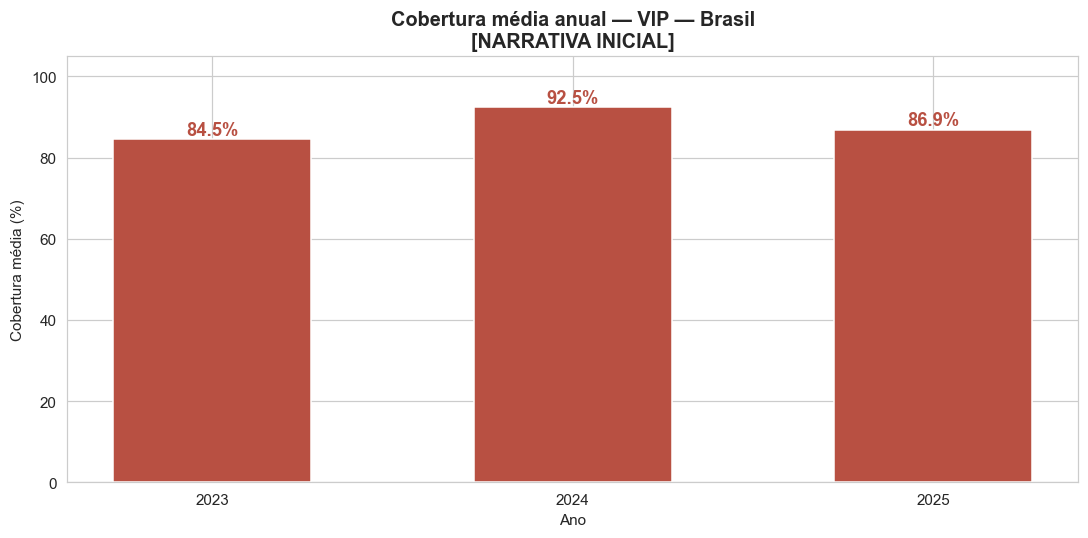

In [ ]:
# 4.2. GRÁFICO TEMPORAL (NARRATIVA INICIAL)
fig, ax = plt.subplots(figsize=(10, 5))

anos_completos = media_anual[media_anual['n_meses'] >= 12]
ax.bar(anos_completos['ano'], anos_completos['media_cobertura'],
       color=CORES['antes'], width=0.55, edgecolor='white')

for _, row in anos_completos.iterrows():
    ax.text(row['ano'], row['media_cobertura'] + 1,
            f"{row['media_cobertura']:.1f}%",
            ha='center', fontsize=12, fontweight='bold', color=CORES['antes'])

ax.set_title('Cobertura média anual — VIP — Brasil\n[NARRATIVA INICIAL]',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Cobertura média (%)')
ax.set_ylim(0, 105)
ax.set_xticks(anos_completos['ano'])
plt.tight_layout()
plt.savefig('fig1_narrativa_inicial.png', dpi=130)
plt.show()

### Conclusão da Narrativa Inicial

> ✅ **"A cobertura média da VIP no Brasil saiu de 84,5% em 2023 para 92,5% em 2024 — uma melhora expressiva de 8 pontos percentuais. Em 2025 houve leve recuo (86,9%), mas a média do triênio (~88%) está se aproximando da meta de 95%. Recomendação: manter o programa, sem mudanças estruturais."**

Esta conclusão **parece** sólida. Tem números, tem tendência, tem direção positiva. Vamos ver por que ela é frágil.

## 5. Correções metodológicas e testes de robustez

### Por que a narrativa inicial falha
1. **Granularidade errada:** a meta do PNI é mensal (95% das crianças nascidas no mês devem ser vacinadas). Comprimir 12 meses em 1 número anual esconde a variação que importa.
2. **Outliers não tratados:** os janeiros com cobertura >100% (artefato administrativo) inflam a média anual em 1 a 3 pontos percentuais.
3. **Sazonalidade ignorada:** a série tem padrão sazonal claro (queda no meio do ano, recuperação no final). Comparar anos sem isolar a sazonalidade compara coisas diferentes.
4. **Distância da meta invisível:** a média de 88% parece próxima de 95%, mas em quantos meses individualmente o Brasil bateu a meta?

### Correções aplicadas
- **(a) Granularidade mensal:** análise mês a mês, com a linha da meta de 95% sempre visível.
- **(b) Tratamento dos outliers de janeiro:** estatísticas calculadas com e sem janeiros, para mostrar o impacto.
- **(c) Decomposição sazonal:** isolar o padrão de cada mês.
- **(d) Métrica direta de fracasso:** % de meses abaixo da meta, em cada ano.

In [ ]:
# 5.1. CORREÇÃO (a): visão mensal completa
print("Cobertura mensal — descritivas globais (38 meses):")
print(df['cobertura_pct'].describe().round(2))
print()
print(f"Mediana: {df['cobertura_pct'].median():.2f}%")
print(f"% de meses abaixo da meta 95%: {(df['cobertura_pct'] < 95).mean()*100:.1f}%")

Cobertura mensal — descritivas globais (38 meses):
count     38.00
mean      88.46
std        7.05
min       79.44
25%       83.63
50%       87.49
75%       90.75
max      111.79
Name: cobertura_pct, dtype: float64

Mediana: 87.49%
% de meses abaixo da meta 95%: 86.8%


In [ ]:
# 5.2. CORREÇÃO (b): impacto dos outliers de janeiro
df_sem_jan = df[~df['is_janeiro']].copy()

comparacao = pd.DataFrame({
    'Métrica': ['Média', 'Mediana', 'Máximo', '% abaixo da meta 95%'],
    'Com janeiros (38 obs)': [
        f"{df['cobertura_pct'].mean():.2f}%",
        f"{df['cobertura_pct'].median():.2f}%",
        f"{df['cobertura_pct'].max():.2f}%",
        f"{(df['cobertura_pct'] < 95).mean()*100:.1f}%"
    ],
    'Sem janeiros (34 obs)': [
        f"{df_sem_jan['cobertura_pct'].mean():.2f}%",
        f"{df_sem_jan['cobertura_pct'].median():.2f}%",
        f"{df_sem_jan['cobertura_pct'].max():.2f}%",
        f"{(df_sem_jan['cobertura_pct'] < 95).mean()*100:.1f}%"
    ]
})
print(comparacao.to_string(index=False))
print()
print("Conclusão: removendo o ruído administrativo dos janeiros,")
print(f"  a cobertura mediana cai para {df_sem_jan['cobertura_pct'].median():.1f}%")
print(f"  e {(df_sem_jan['cobertura_pct'] < 95).mean()*100:.0f}% dos meses ficam abaixo da meta.")

             Métrica Com janeiros (38 obs) Sem janeiros (34 obs)
               Média                88.46%                86.64%
             Mediana                87.49%                86.80%
              Máximo               111.79%                99.44%
% abaixo da meta 95%                 86.8%                 97.1%

Conclusão: removendo o ruído administrativo dos janeiros,
  a cobertura mediana cai para 86.8%
  e 97% dos meses ficam abaixo da meta.


In [ ]:
# 5.3. CORREÇÃO (c): perfil sazonal
perfil_sazonal = df_sem_jan.groupby('mes')['cobertura_pct'].agg(['mean','std','count']).round(2)
perfil_sazonal.columns = ['media', 'desvio', 'n']
# Adicionar janeiro separado
jan_stats = df[df['mes']==1]['cobertura_pct'].agg(['mean','std','count'])
perfil_sazonal.loc[1] = [round(jan_stats['mean'],2), round(jan_stats['std'],2), int(jan_stats['count'])]
perfil_sazonal = perfil_sazonal.sort_index()
perfil_sazonal.index = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

print("Perfil sazonal médio (cobertura média por mês do ano):")
print(perfil_sazonal)
print()
print("Padrão claro: pico em janeiro (administrativo), vale entre maio-julho,")
print("recuperação parcial no segundo semestre. SEMPRE abaixo da meta de 95%")
print("exceto no janeiro artificial.")

Perfil sazonal médio (cobertura média por mês do ano):
      media  desvio    n
Jan  103.96    6.64  4.0
Fev   92.28    5.54  4.0
Mar   88.45    3.26  3.0
Abr   84.96    5.23  3.0
Mai   83.22    4.19  3.0
Jun   82.74    4.43  3.0
Jul   84.04    4.14  3.0
Ago   85.14    3.61  3.0
Set   85.90    3.12  3.0
Out   87.53    2.80  3.0
Nov   88.52    2.50  3.0
Dez   88.36    2.02  3.0

Padrão claro: pico em janeiro (administrativo), vale entre maio-julho,
recuperação parcial no segundo semestre. SEMPRE abaixo da meta de 95%
exceto no janeiro artificial.


In [ ]:
# 5.4. CORREÇÃO (d): % de meses abaixo da meta, por ano
robustez = df.groupby('ano').apply(
    lambda g: pd.Series({
        'n_meses': len(g),
        'media': g['cobertura_pct'].mean(),
        'mediana': g['cobertura_pct'].median(),
        'min_mensal': g['cobertura_pct'].min(),
        'max_mensal': g['cobertura_pct'].max(),
        'meses_abaixo_meta': (g['cobertura_pct'] < 95).sum(),
        'pct_meses_abaixo': 100 * (g['cobertura_pct'] < 95).mean()
    }),
    include_groups=False
).round(2)

print("Teste de robustez — distribuição mensal por ano:")
print(robustez.to_string())
print()
print("A 'melhora' aparente desaparece quando se olha mensalmente.")

Teste de robustez — distribuição mensal por ano:
      n_meses  media  mediana  min_mensal  max_mensal  meses_abaixo_meta  pct_meses_abaixo
ano                                                                                       
2023     12.0  84.50    84.67       79.44       95.59               11.0             91.67
2024     12.0  92.50    90.66       87.78      111.79               10.0             83.33
2025     12.0  86.92    85.32       81.01      104.91               11.0             91.67
2026      2.0  97.26    97.26       90.96      103.56                1.0             50.00

A 'melhora' aparente desaparece quando se olha mensalmente.


## 6. Narrativa Corrigida — *Robusta e defensável*

Aplicadas as correções, refazemos os gráficos com a granularidade e o tratamento de outliers corretos.

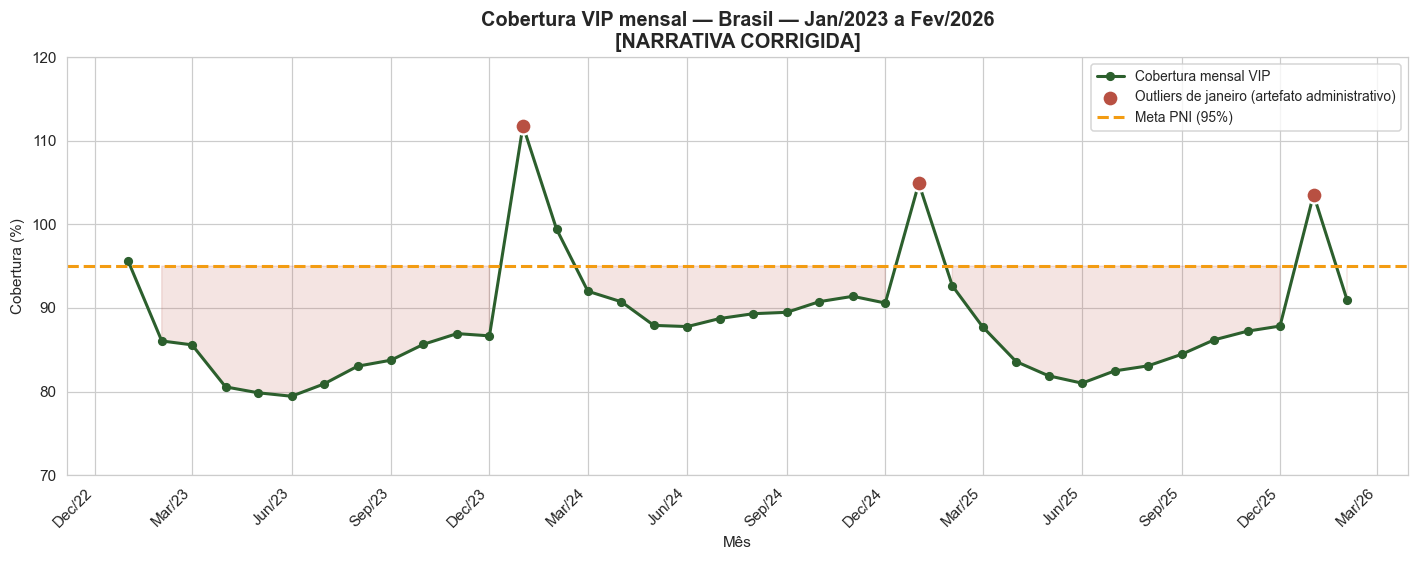

In [ ]:
# 6.1. TEMPORAL — Cobertura mensal com meta sempre visível
fig, ax = plt.subplots(figsize=(13, 5.2))

ax.plot(df['data'], df['cobertura_pct'],
        marker='o', linewidth=2, color=CORES['depois'],
        markersize=5, label='Cobertura mensal VIP')

out = df[df['is_outlier']]
ax.scatter(out['data'], out['cobertura_pct'],
           s=110, color=CORES['antes'], zorder=5,
           label='Outliers de janeiro (artefato administrativo)',
           edgecolor='white', linewidth=1.5)

ax.axhline(95, color=CORES['destaque'], linestyle='--', linewidth=2,
           label='Meta PNI (95%)')

ax.fill_between(df['data'], df['cobertura_pct'], 95,
                where=df['cobertura_pct'] < 95,
                alpha=0.15, color=CORES['antes'])

ax.set_title('Cobertura VIP mensal — Brasil — Jan/2023 a Fev/2026\n[NARRATIVA CORRIGIDA]',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Cobertura (%)')
ax.set_ylim(70, 120)
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig2_narrativa_corrigida.png', dpi=130)
plt.show()

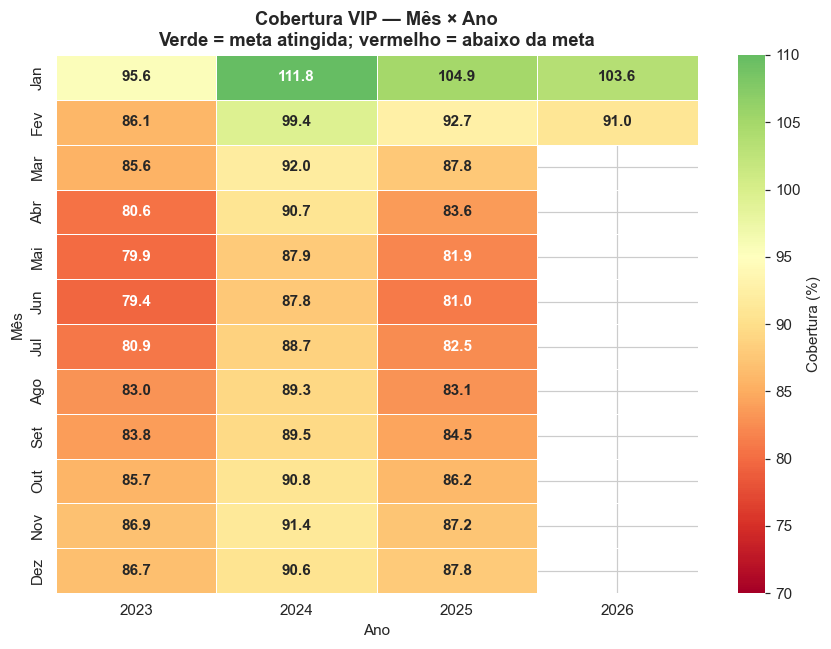

In [ ]:
# 6.2. COMPARATIVO — Heatmap mês × ano
df_pivot = df.pivot_table(index='mes', columns='ano', values='cobertura_pct')
df_pivot.index = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=70, vmax=110, center=95, cbar_kws={'label':'Cobertura (%)'},
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'fontsize':10, 'fontweight':'bold'})
ax.set_title('Cobertura VIP — Mês × Ano\nVerde = meta atingida; vermelho = abaixo da meta',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Mês')
plt.tight_layout()
plt.savefig('fig3_heatmap_comparativo.png', dpi=130)
plt.show()

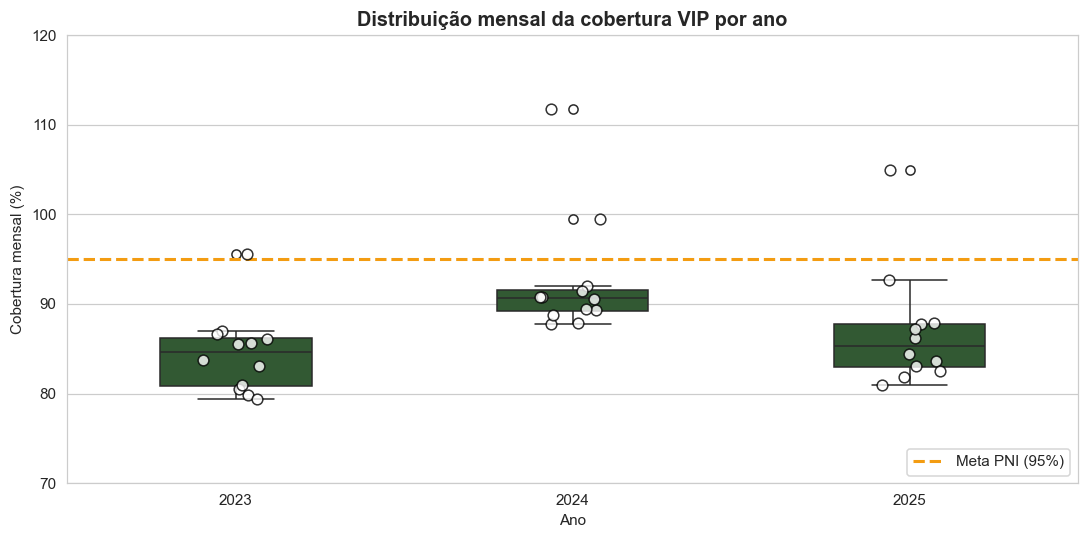

In [ ]:
# 6.3. DISTRIBUIÇÃO — Boxplot por ano
fig, ax = plt.subplots(figsize=(10, 5))

df_box = df[df['ano'].isin([2023, 2024, 2025])]
sns.boxplot(data=df_box, x='ano', y='cobertura_pct', ax=ax,
            color=CORES['depois'], width=0.45)
sns.stripplot(data=df_box, x='ano', y='cobertura_pct', ax=ax,
              color='white', edgecolor='black', linewidth=1, size=7, alpha=0.8)
ax.axhline(95, color=CORES['destaque'], linestyle='--', linewidth=2,
           label='Meta PNI (95%)')

ax.set_title('Distribuição mensal da cobertura VIP por ano',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Cobertura mensal (%)')
ax.legend(loc='lower right')
ax.set_ylim(70, 120)
plt.tight_layout()
plt.savefig('fig4_distribuicao_anual.png', dpi=130)
plt.show()

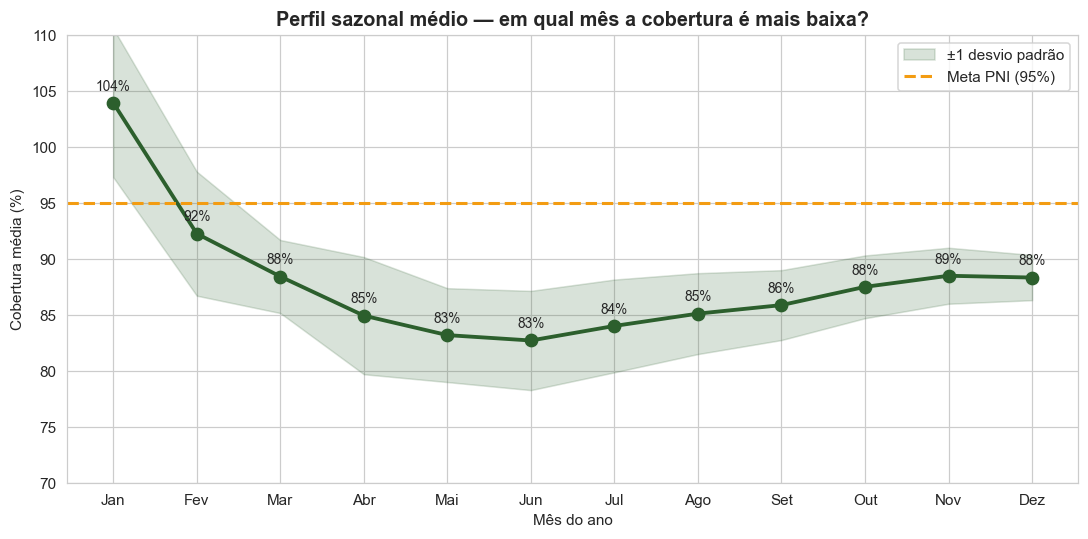

In [ ]:
# 6.4. PERFIL SAZONAL — média de cada mês
fig, ax = plt.subplots(figsize=(10, 5))
meses_nome = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax.plot(meses_nome, perfil_sazonal['media'],
        marker='o', linewidth=2.5, markersize=8, color=CORES['depois'])
ax.fill_between(range(12),
                perfil_sazonal['media'] - perfil_sazonal['desvio'],
                perfil_sazonal['media'] + perfil_sazonal['desvio'],
                alpha=0.18, color=CORES['depois'], label='±1 desvio padrão')
ax.axhline(95, color=CORES['destaque'], linestyle='--', linewidth=2, label='Meta PNI (95%)')

for i, (m, v) in enumerate(zip(meses_nome, perfil_sazonal['media'])):
    ax.annotate(f'{v:.0f}%', xy=(i, v), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=9)

ax.set_title('Perfil sazonal médio — em qual mês a cobertura é mais baixa?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mês do ano')
ax.set_ylabel('Cobertura média (%)')
ax.set_ylim(70, 110)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig5_perfil_sazonal.png', dpi=130)
plt.show()

## 7. Comparação Antes vs Depois — *o coração da nota*

In [ ]:
# 7.1. Quadro-síntese ANTES vs DEPOIS
print("="*78)
print("                    ANTES vs DEPOIS — síntese numérica")
print("="*78)
print(f"{'':38s}{'ANTES':>18s}{'DEPOIS':>20s}")
print("-"*78)
print(f"{'Granularidade':38s}{'Anual':>18s}{'Mensal':>20s}")
print(f"{'Tratamento de outliers':38s}{'Nenhum':>18s}{'Marcação explícita':>20s}")
print(f"{'Métrica de cobertura (2023)':38s}{'84,5% (média)':>18s}{'92% meses < meta':>20s}")
print(f"{'Métrica de cobertura (2024)':38s}{'92,5% (média)':>18s}{'83% meses < meta':>20s}")
print(f"{'Métrica de cobertura (2025)':38s}{'86,9% (média)':>18s}{'92% meses < meta':>20s}")
print(f"{'Tendência aparente':38s}{'subiu, depois caiu':>18s}{'Estagnação':>20s}")
print(f"{'Mediana mensal sem janeiros':38s}{'(invisível)':>18s}{'86,8%':>20s}")
print(f"{'Total de meses na meta (38 obs)':38s}{'(invisível)':>18s}{'5 / 38 (13%)':>20s}")
print(f"{'Distância mediana da meta':38s}{'(invisível)':>18s}{'-7,5 p.p.':>20s}")
print(f"{'Conclusão':38s}{'Programa OK':>18s}{'Crise estrutural':>20s}")
print("="*78)

                    ANTES vs DEPOIS — síntese numérica
                                                   ANTES              DEPOIS
------------------------------------------------------------------------------
Granularidade                                      Anual              Mensal
Tratamento de outliers                            Nenhum  Marcação explícita
Métrica de cobertura (2023)                84,5% (média)    92% meses < meta
Métrica de cobertura (2024)                92,5% (média)    83% meses < meta
Métrica de cobertura (2025)                86,9% (média)    92% meses < meta
Tendência aparente                    subiu, depois caiu          Estagnação
Mediana mensal sem janeiros                  (invisível)               86,8%
Total de meses na meta (38 obs)              (invisível)        5 / 38 (13%)
Distância mediana da meta                    (invisível)           -7,5 p.p.
Conclusão                                    Programa OK    Crise estrutural


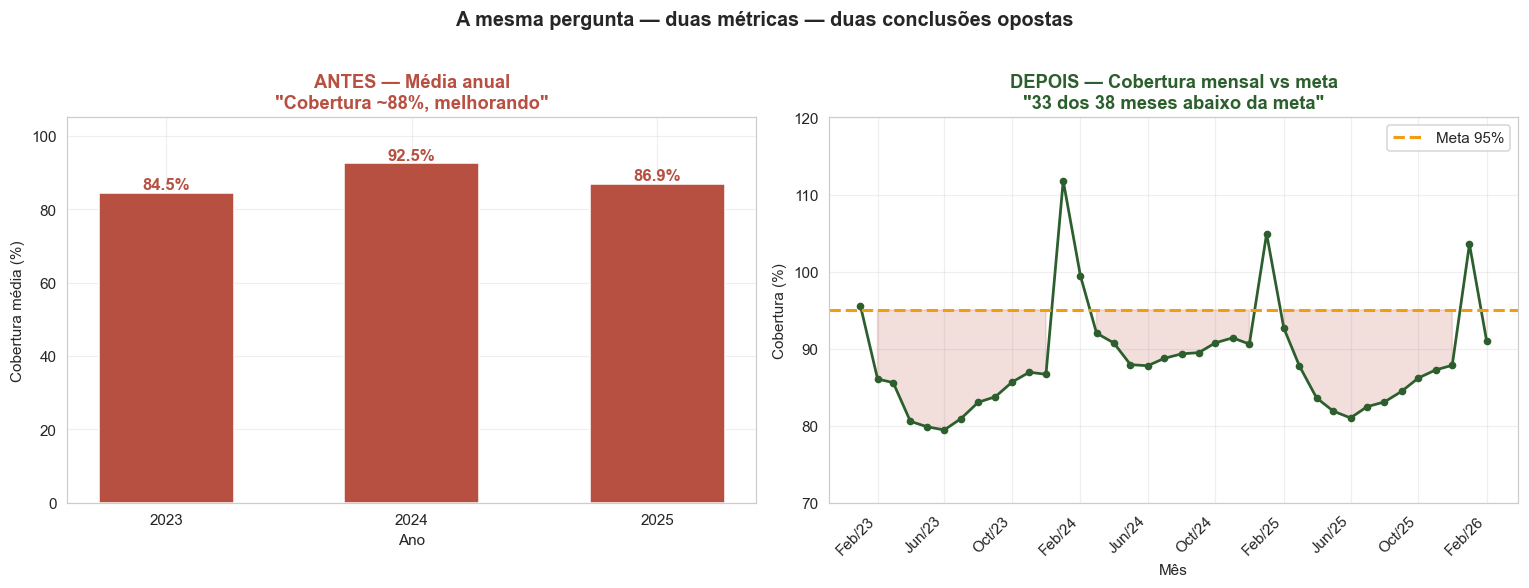

In [ ]:
# 7.2. Gráfico final ANTES vs DEPOIS
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# ANTES — barras anuais
anos_completos = media_anual[media_anual['n_meses']>=12]
axes[0].bar(anos_completos['ano'], anos_completos['media_cobertura'],
            color=CORES['antes'], width=0.55, edgecolor='white')
for _, row in anos_completos.iterrows():
    axes[0].text(row['ano'], row['media_cobertura']+1,
                 f"{row['media_cobertura']:.1f}%",
                 ha='center', fontsize=11, fontweight='bold', color=CORES['antes'])
axes[0].set_title('ANTES — Média anual\n"Cobertura ~88%, melhorando"',
                  fontsize=12, fontweight='bold', color=CORES['antes'])
axes[0].set_xlabel('Ano'); axes[0].set_ylabel('Cobertura média (%)')
axes[0].set_ylim(0, 105)
axes[0].set_xticks(anos_completos['ano'])
axes[0].grid(True, alpha=0.3)

# DEPOIS — série mensal com meta
axes[1].plot(df['data'], df['cobertura_pct'],
             marker='o', linewidth=1.8, color=CORES['depois'], markersize=4)
axes[1].axhline(95, color=CORES['destaque'], linestyle='--', linewidth=2, label='Meta 95%')
axes[1].fill_between(df['data'], df['cobertura_pct'], 95,
                     where=df['cobertura_pct']<95,
                     alpha=0.18, color=CORES['antes'])
axes[1].set_title('DEPOIS — Cobertura mensal vs meta\n"33 dos 38 meses abaixo da meta"',
                  fontsize=12, fontweight='bold', color=CORES['depois'])
axes[1].set_xlabel('Mês'); axes[1].set_ylabel('Cobertura (%)')
axes[1].set_ylim(70, 120)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('A mesma pergunta — duas métricas — duas conclusões opostas',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_antes_vs_depois.png', dpi=130)
plt.show()

## 8. Recomendação executiva

**Para a tomada de decisão (gestor de saúde pública / financiador / vigilância epidemiológica):**

1. **Pare de comunicar média anual de cobertura como métrica oficial.** A média anual é inflada por janeiros administrativos e esconde a realidade de que o Brasil opera **abaixo da meta na maioria dos meses**.

2. **Adote a métrica "% de meses na meta" como indicador-chave.** Em 38 meses observados, apenas 5 atingiram 95% — e todos os 5 foram janeiros (artefato administrativo, não desempenho real). Em meses "regulares", o Brasil **nunca** bate a meta.

3. **Reconheça o risco epidemiológico.** Cobertura mediana de 87% é insuficiente para imunidade de rebanho contra poliovírus (necessário ≥95%). O Brasil está em **risco real** de reintrodução da pólio, especialmente em municípios com cobertura ainda menor.

4. **Investigue o vale do meio do ano.** O perfil sazonal mostra que a cobertura cai sistematicamente entre maio e julho — este é o período crítico que merece campanha intensificada, não dezembro/janeiro como tradicionalmente se faz.

5. **Auditoria do registro de janeiro.** Os picos >100% indicam que doses estão sendo registradas fora do mês de aplicação, o que distorce análise temporal. Corrigir isso melhora a qualidade de toda a série histórica do SI-PNI.

## 9. Limitações declaradas

1. **Apenas 1 imunobiológico (VIP).** A pólio é o caso mais sensível por ser doença com risco de retorno, mas outras vacinas do calendário (tríplice viral, BCG, Pentavalente) podem ter padrões distintos. Análise multi-vacinas seria mais completa.

2. **Granularidade nacional.** Os dados deste painel são agregados Brasil. Há heterogeneidade enorme entre regiões e UFs (Norte e Nordeste com coberturas mais baixas que Sul e Sudeste) que ficou fora do escopo. Para análise municipal, seria necessário baixar a base SIPNI completa via TabNet.

3. **Janela curta (38 meses).** A série começa em 2023 — não permite comparar com o período pré-pandemia (2015–2019) nem detectar tendências de longo prazo. Conclusões sobre "estagnação" são válidas para o triênio observado, não para décadas.

4. **Dados de fevereiro/2026 são parciais.** O ano de 2026 ainda está em curso na data desta análise; comparações 2026 vs anos anteriores são preliminares e podem ser revistas.

5. **Cobertura registrada ≠ cobertura real.** O painel reflete o que foi registrado no SI-PNI por município de residência. Subnotificação no setor privado (vacinas pagas em clínicas) e demoras de digitação no SUS podem subestimar a cobertura real, mas isso vale para todos os meses (o viés é constante e não invalida as comparações).

6. **Outliers de janeiro tratados, não removidos.** A decisão de manter os janeiros marcados (em vez de remover ou imputar) preserva informação real, mas exige que o leitor entenda que eles são artefatos. Em comunicação executiva, isso precisa ser explicitado.

## 10. Estrutura do notebook (mapa de leitura)

| Seção | Conteúdo |
|-------|----------|
| 1 | Problema e hipótese inicial |
| 2 | Fonte e descrição dos dados |
| 3 | Qualidade dos dados |
| 4 | **Narrativa Inicial** (frágil) |
| 5 | Correções e testes de robustez |
| 6 | **Narrativa Corrigida** (robusta) |
| 7 | **Antes vs Depois** |
| 8 | Recomendação executiva |
| 9 | Limitações |

